
# **Türkiye Ulusal Gözlemevleri Bünyesindeki Erzurum DAG Yerleşkesi ve Antalya TUG Yerleşkesi için Gece Işıklarının Analizi**

## **Eğitim ve Uygulama Serisi - Bölüm 2: Suomi NPP VIIRS NTL Veri Temini ve Veri İşleme**

- Bu eğitim serisi, **TÜBİTAK** 3501 Kariyer Geliştirme Programı kapsamında desteklenen **"124F297"** numaralı proje çerçevesinde geliştirilmiştir.

- **Dokümanı Hazırlayanlar: Dr. Kazım Kaba, Dr. Funda Aksoy, Doç. Dr. İlham Nasıroğlu, Fethullah Polat, Sima Aydın, Rabia Beyza Türkmen, Yusuf Sağlam, Prof. Dr. Cahit Yeşilyaprak, Prof. Dr. H. Mustafa Kandırmaz**

- Bu notebook dosyasında yer alan bazı analiz yaklaşımları, projeksiyon ve modelleme adımları **Kaba vd. (2026b)** tarafından yürütülen güncel araştırma çalışmaları temel alınarak kurgulanmıştır.

- Bu notebook serisi, projemizin uzaktan algılama ve veri analizi süreçlerini eğitim amacıyla paylaşmak ve açık bilim ilkelerini desteklemek için hazırlanmıştır.

- Bu bölümde, Suomi NPP uydusunun VIIRS sensöründen elde edilen gece ışıkları verilerinin (VNP46A1 ve VNP46A2 günlük ürünleri) NASA LAADS DAAC platformundan nasıl temin edileceği, gdal kütüphanesi kullanılarak WGS84 koordinat sistemine nasıl projekte edileceği, nasıl mozaikleneceği ve Türkiye sınırlarına göre nasıl maskeleneceği adım adım anlatılmaktadır.

- Ayrıca bu ön işleme adımlarının devamında; günlük uydu radyans pikselleri ile yer tabanlı SQM gözlem istasyonlarının zaman ve konum (koordinat) bilgileri eşleştirilmiş, elde edilen eş zamanlı değerler üzerinden log-doğrusal regresyon modelleri kurgulanarak uydudan alınan yukarı yönlü radyansın yer seviyesindeki gökyüzü parlaklığına dönüşümünü sağlayan bölgesel transfer fonksiyonları türetilmiştir.



## **2.1 Suomi NPP VIIRS NTL Verilerinin İndirilmesi**

- NASA LAADS DAAC servisine [BURADAN](https://ladsweb.modaps.eosdis.nasa.gov/) üye olarak veriler indirilebilir.

- Veri indirebilmek için öncelikle bir NASA Earthdata hesabı oluşturmanız ve giriş yapmanız gerekmektedir (verileri üyeliksiz inceleme mümkündür).

- Giriş yaptıktan sonra **"Data Accsess > Find Data"** sekmeleri kullanılırsa alt görseldeki ekran gelecektir.

- Sayfada **"1 PRODUCTS"** menüsünden **VIIRS: Suomi-NPP** sensörünü,  **VIIRS Collection 2 - Level 1, Atmosphere, Land (Archive Set 5200)** koleksiyonunu ve **Nighttime Lights > VNP46A4** ürününü seçiyoruz (A1 ve A2: Günlük, A3: Aylık, A4:Yıllık).



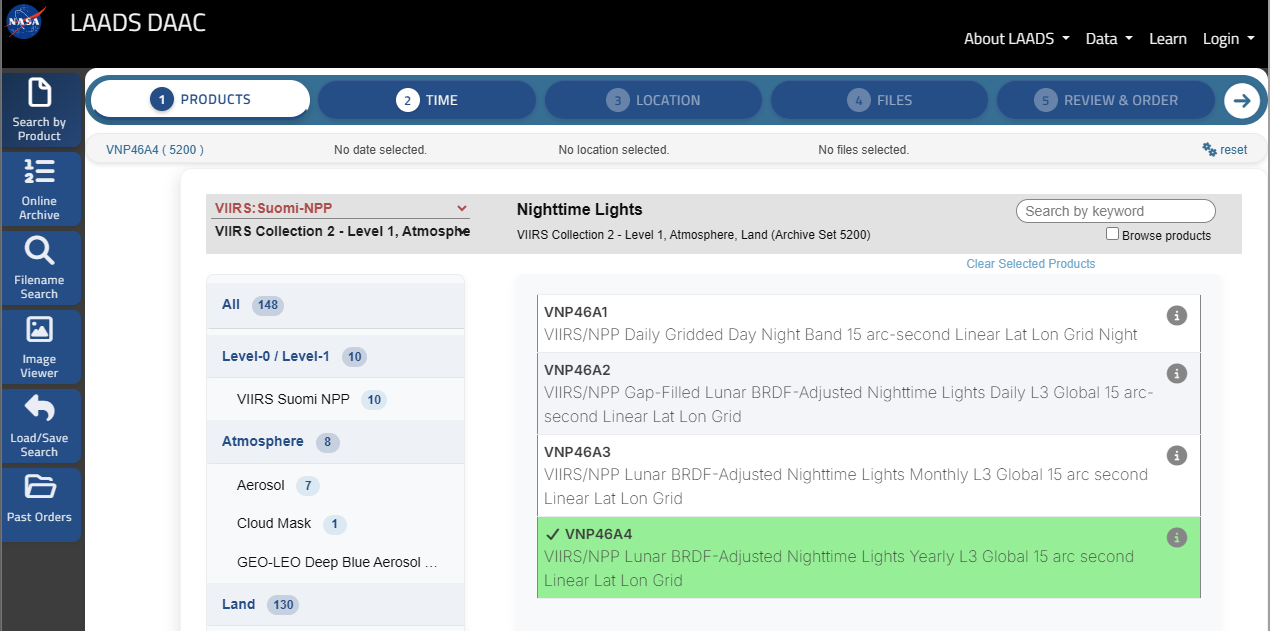



- Şimdi **"2 TIME"** sekmesinden zamanı tanımlamalıyız. Var olan tüm zamanların verisini almak için 2012-01-01 ve 2025-12-31 aralığını ekleyip (Add Date) "Coverage Selection" bölümünde **Night** işaretliyoruz.



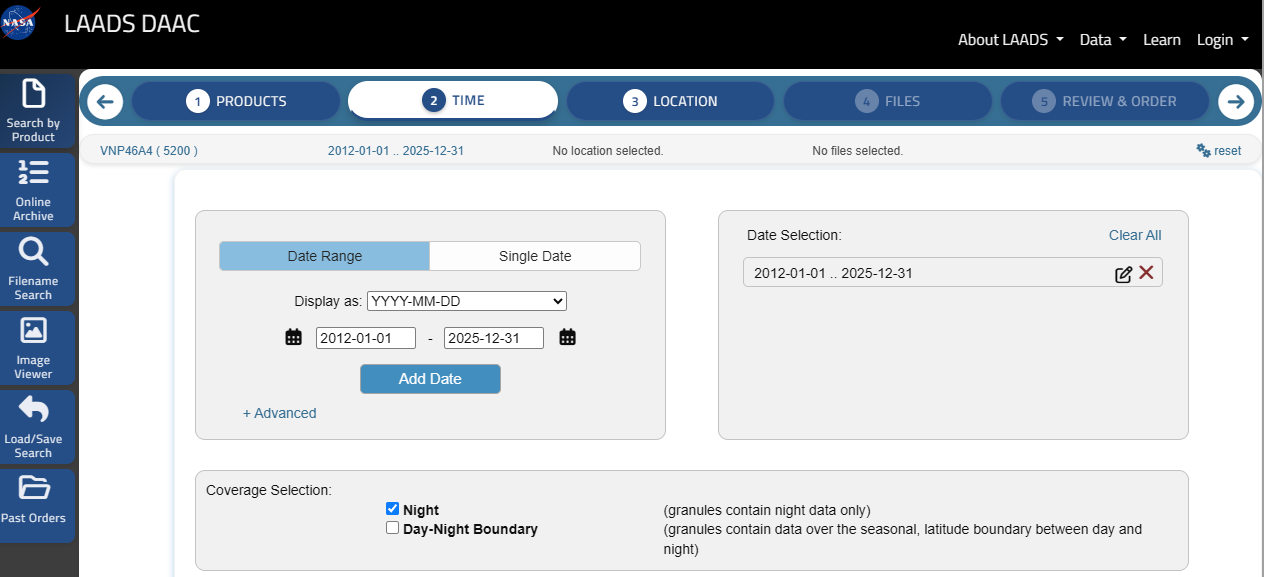



- **"3 LOCATION"** sekmesinden verilerin kapsayacağı alan belirlenecek. **"SELECT AREA OF INTERSET"** açılır penceresinden **"Countries > Türkiye"** işaretliyoruz (haritada alana mouse sol tık). Türkiye genelini kapsamak için 6 adet grid hücresinin (Sinüzoidal Grid Sistemi) indirilmesi gerekmektedir (h20v04, h20v05, h21v04, h21v05, h22v04, h22v05). Bu işlem sonraki sekmede ("4 FILES") gerçekleştirilecektir.




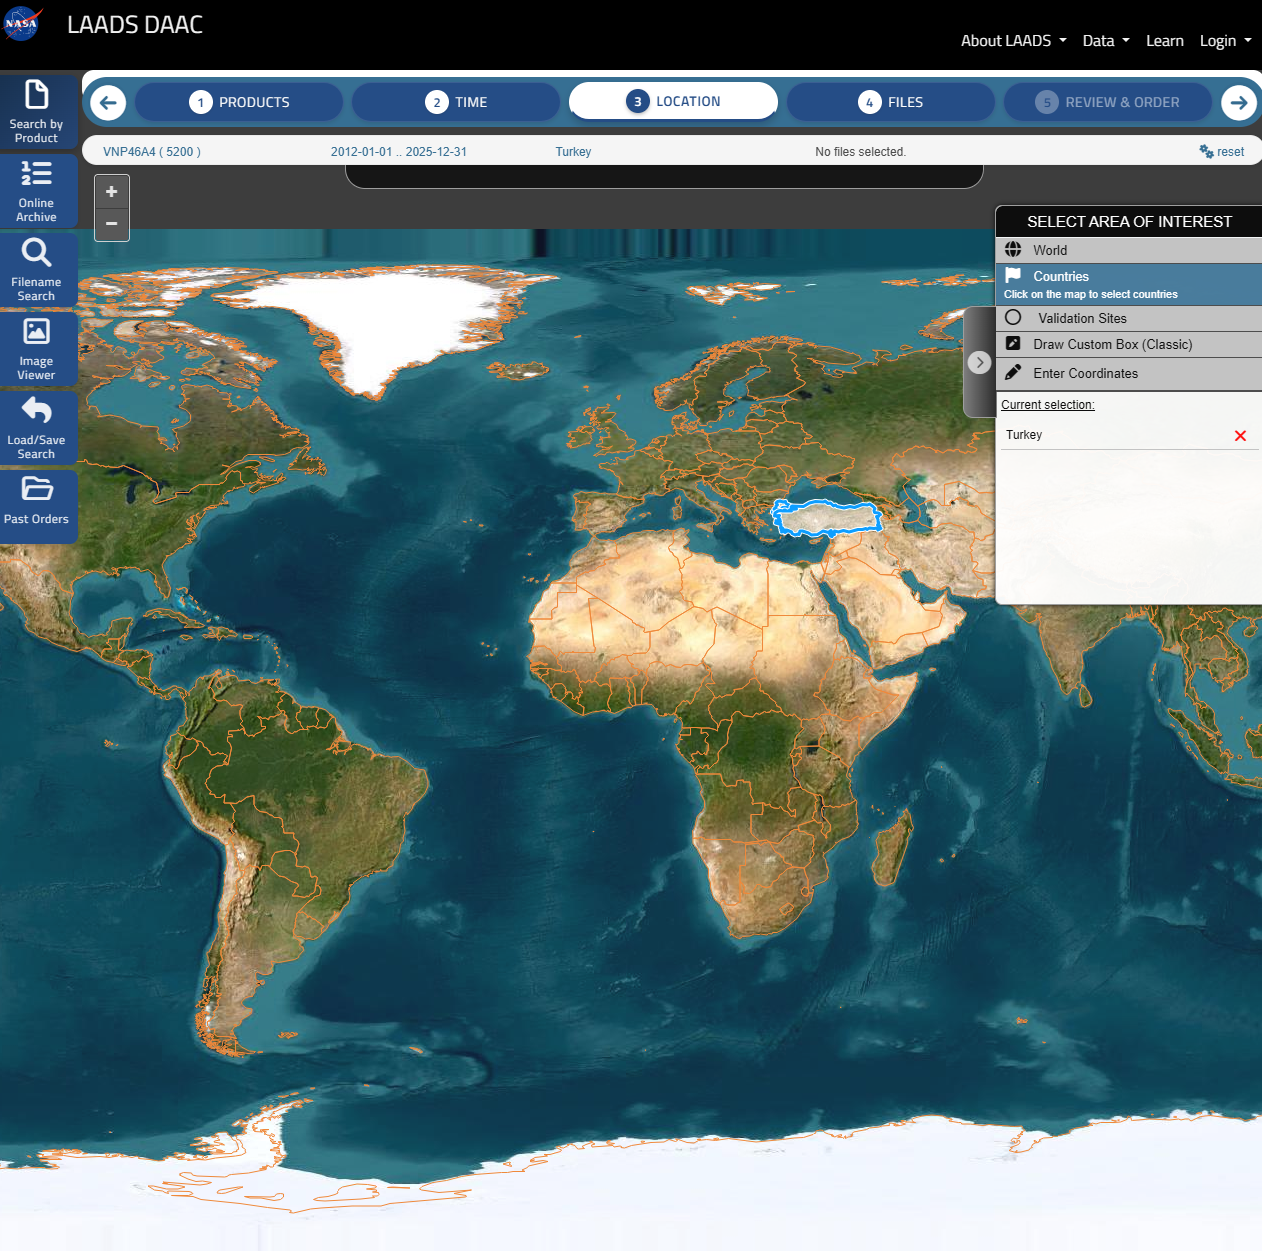



- Belirtilen kriterlerdeki veriler **"4 FILES"** menüsünde listenecektir. Listelenen tüm verileri seçtikten (**"Select All"**) sonra **"5 REVIEW & ORDER"** sekmesine geçiyoruz.



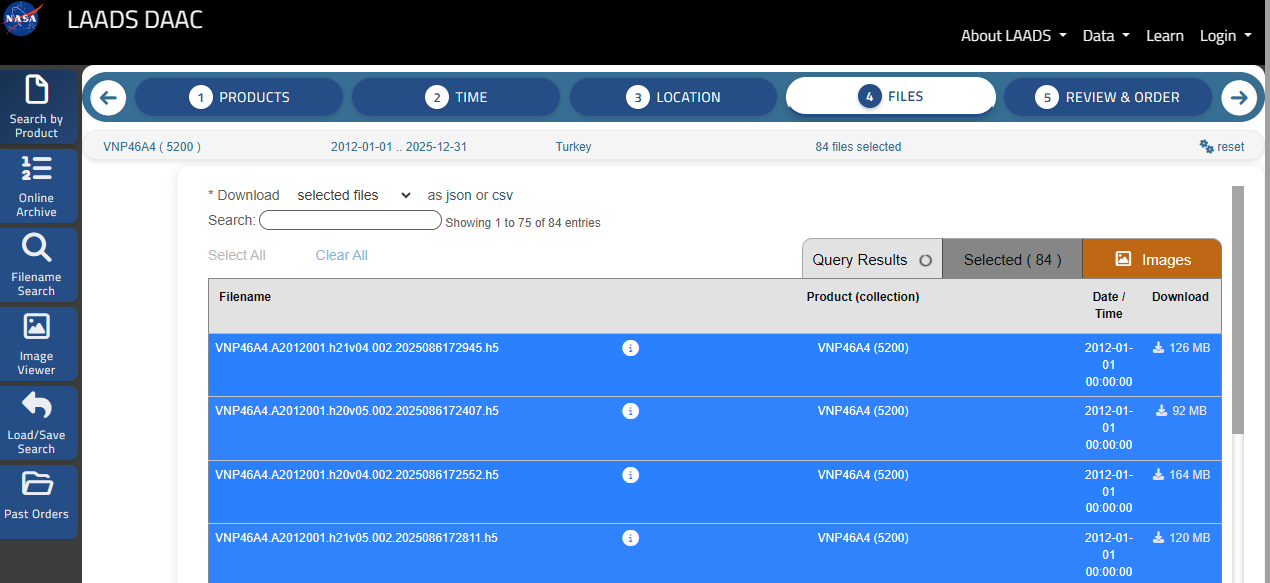



- **"5 REVIEW & ORDER"** sekmesinde verileri sipariş edeceğiz, öncesinde istenecek veriler içerik ve format gibi özellikleri bakımından özelleştirilebilir. Ancak biz hiç bir düzenleme yapmadan (**"Submit Order"**) devam ediyoruz.



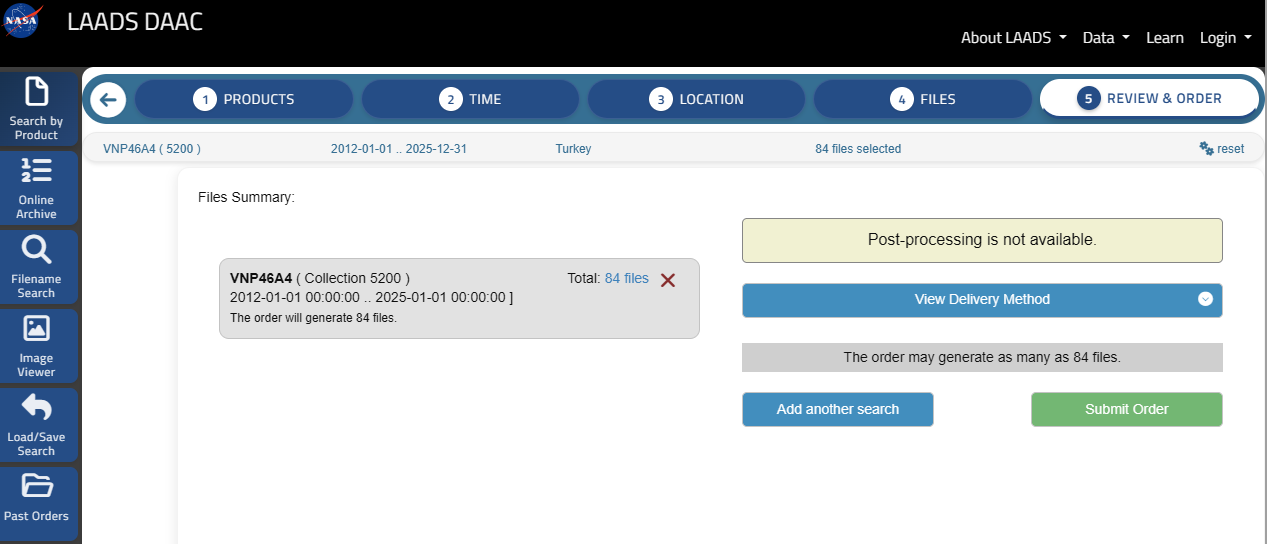



- Veriler hazırlandığında indirilecek linki içeren mail gelecektir veya **"Login > Orders"** menüsü kullanılabilir.



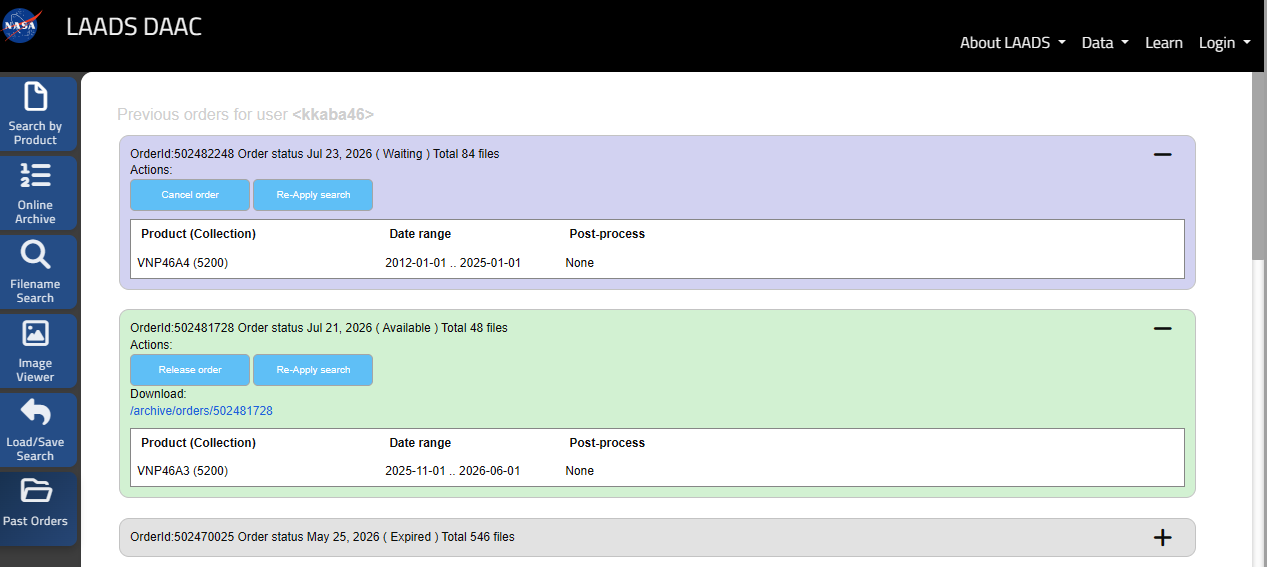



- Verileri indirmenin bir yolu işletim sisteminizin komut satırında (windows > komut istemi) **wget** programını kullanmaktır. Aşağıda örnek komut verilmiştir. "OrderId" yerine sipariş kodunuzu, "user token" yerine size özel anahtarı ve "P" parametresine verilerin indirileceği disk yolunuzu yazmalısınız. Program doğru çalıştığında alttaki ekran görüntüsü görülecektir. 

wget -e robots=off -m -np -R .html,.tmp -nH --cut-dirs=3 "https://ladsweb.modaps.eosdis.nasa.gov/archive/orders/ **OrderId** /" --header "Authorization: Bearer **user token**" -P **E:\\...\VNP46A4**



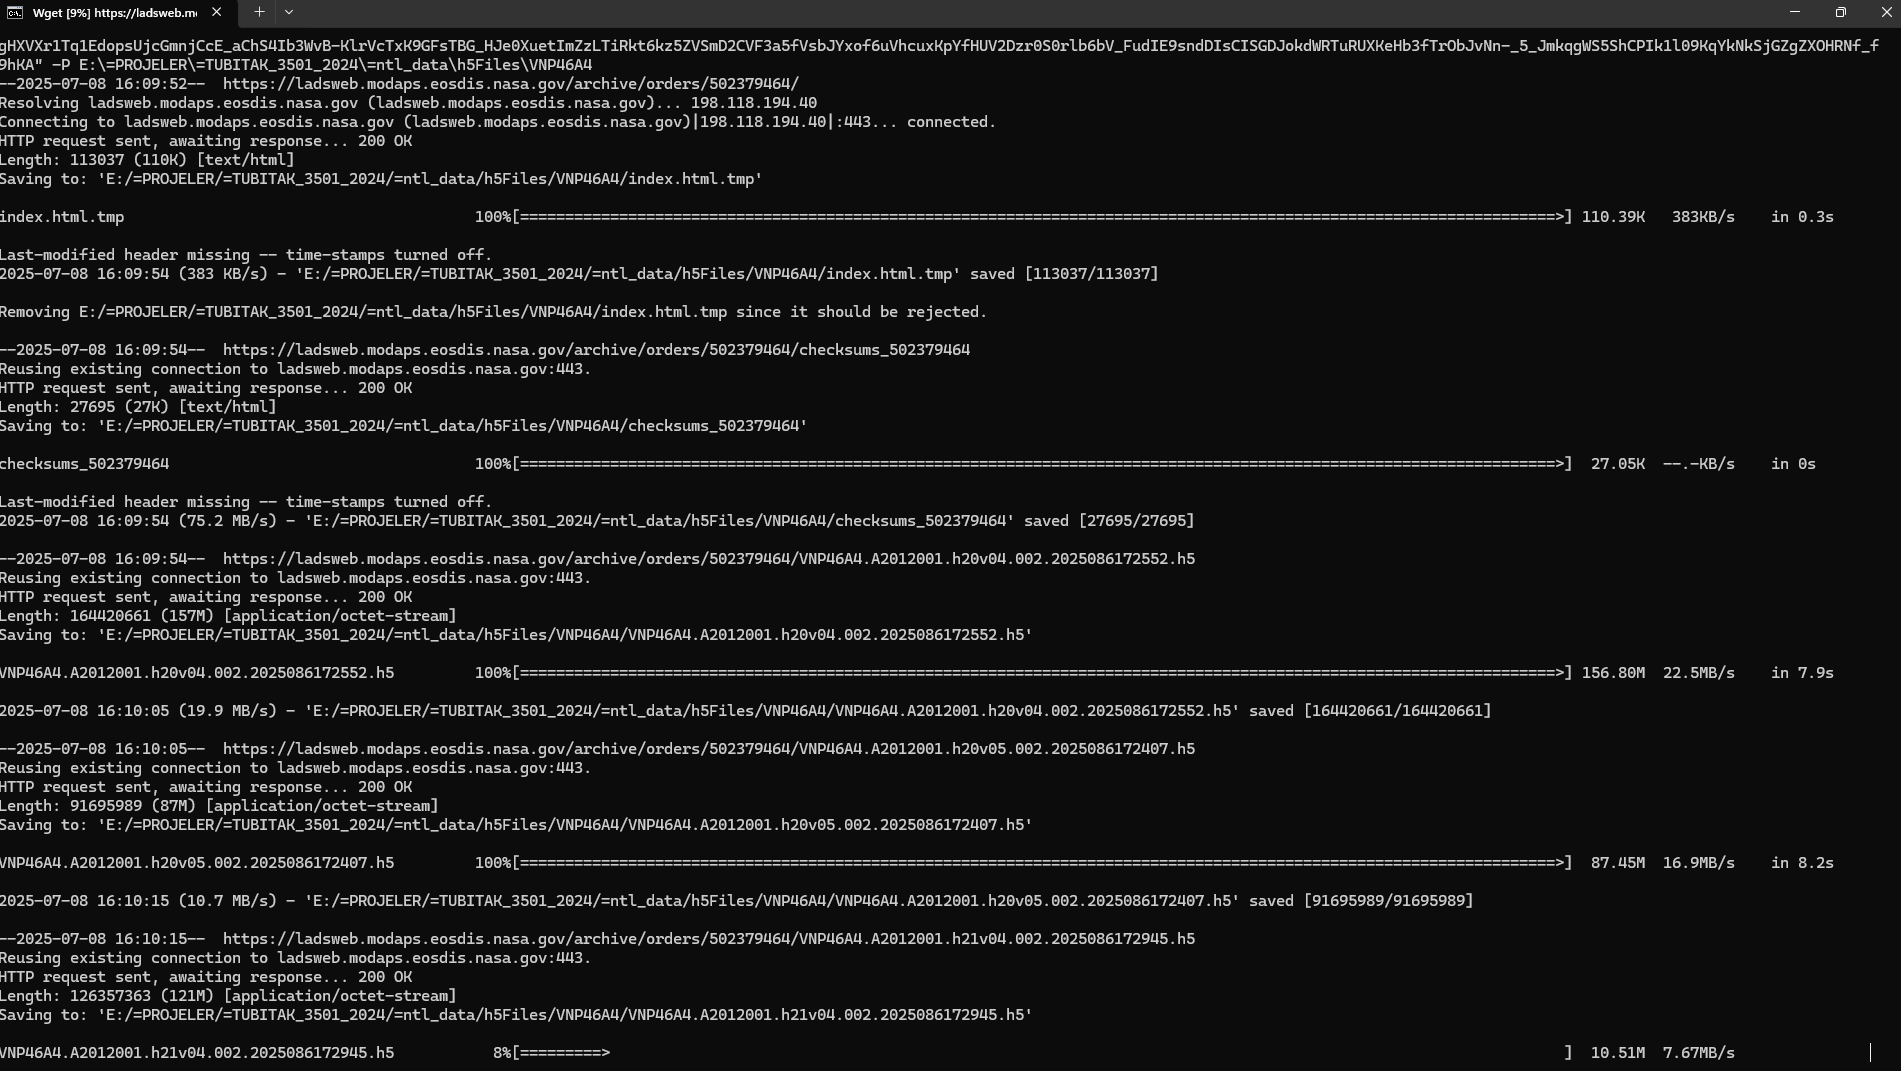



- Yukarıdaki anlatımda LAADS DAAC servisinden VNP46A4 yıllık ortalama NTL verileri indirildi. Diğer NTL verileri de benzer şekilde temin edilebilir.

- Ayrıca bu servisten pek çok uydu, sensör ve ürün verileri farklı koleksiyonlarda/versiyonlarda temin edilebilir.

- Suomi NPP VIIRS, Dünya sistem bilimi ve uygulamaları için uygun olan gece görünür ve yakın kızılötesi ışığın küresel günlük ölçümlerini sağlayan bir DNB (Day-Night Band) kanalına sahiptir.

- VIIRS DNB'nin düşük ışık koşullarındaki ultra hassasiyeti, önceki DMSP/OLS gece ışıkları ürünleriyle karşılaştırıldığında sensör çözünürlüğü ve kalibrasyonunda önemli iyileştirmeler sunan, bilimsel kalitede gece ürünleri üretmektedir.

- VIIRS DNB ürünleri hem gece olaylarının büyüklüğünü ve izini hem de insan kaynaklı ışık emisyonu kaynaklarının daha iyi izlemesini sağlamaktadır.

- VNP46A4, günlük (VNP46A1 ve VNP46A2) verilerden üretilen yıllık kompozitler sağlayar.

- Uzun adı "VIIRS/NPP Lunar BRDF-Adjusted Nighttime Lights Yearly L3 Global 15 arc second Linear Lat Lon Grid" olan bu ürün 28 katman içerir. Katmanlar, kara-su maskesi ve enlem-boylam koordinat bilgilerinin yanısıra farklı zenit açılarında (nadire yakın, nadir dışı ve tüm açılar) ve karla kaplı ve karsız durumlar için NTL kompoziti, gözlem sayısı, kalite ve standart sapma bilgileri sağlar.

**Kaynak:**

- https://ladsweb.modaps.eosdis.nasa.gov/missions-and-measurements/products/VNP46A4/
- https://ladsweb.modaps.eosdis.nasa.gov/filespec/VIIRS/1/VNP46A4



## **2.2 VIIRS NTL Verilerinin İşlenmesi**


- Yukarıda anlatıldığı şekilde verilerin temin edilip yerel diske eklenmesi ile sonraki aşama verilerin kullanımı için hazırlanmasıdır.

- VIIRS NTL VNP46A* ürünleri son kullanıcıya yönelik (Seviye 3; Level 3) verileri olması nedeniyle kullanımı kolaydır.

- VIIRS NTL VNP46A* ürünleri HDF5 formatındadır ve yaklaşık 15 ark-saniye (~500 metre) çözünürlükte coğrafi grid yapısına sahiptir.

- Veriler 10X10 derecelik gridler şeklinde sunulduğu için çalışma alanını (Türkiye) altı grid kapsıyor. Bu altı grid birleştirildiğinge (merging/mosaicing) 30-50 Kuzey enlemleri ile 20-50 Doğu boylamları arası kapsanıyor.

- Sadece Türkiye ve kara üzerindeki NTL değerleri ile ilgilendiğimiz için vektör veri kullanarak Türkiye alt alanını elde edip (clipping/cropping) dosyalar daha sonra kullanılmak üzere arşivleniyor.



## **2.2.1 VNP46A1 ve VNP46A2 Günlük Verilerinin işlenmesi**

- Yer tabanlı SQM gözlemlerimizi uydudan elde edilen gece ışığı emisyonlarıyla piksel bazında doğrulayabilmek ve karşılaştırabilmek amacıyla, NASA'nın günlük bazda sunduğu yüksek çözünürlüklü VNP46A1 (DNB_At_Sensor_Radiance) ve VNP46A2 (Gap_Filled_DNB_BRDF-Corrected_NTL) ürünlerini işlememiz gerekmektedir.

- Bu bölümde; **h5** (HDF5) formatında indirilen günlük uydu dosyalarını Python ortamında **gdal** kütüphanesini kullanarak işleyeceğiz.

- NASA sınıflandırma standartlarında her iki ürün de küresel grid yapısına oturtulmuş Level-3 düzeyindedir; ancak aralarındaki temel işlevsel fark, VNP46A2 ürününün atmosferik düzeltmelerin yanı sıra Ay ışığı radyansını tamamen arındırarak insan kaynaklı antropojenik emisyonları izole etmesi, VNP46A1 ürününün ise sensörün algıladığı ham radyans değerlerini atmosferik düzeltmesiz ve ay ışığı maskelemesiz olarak sunmasıdır.

- Geliştirdiğimiz Python akış şeması; ham h5 formatındaki bu günlük uydu dosyalarını gdal kütüphanesi kullanarak işlemektedir. Sistem; ham HDF5 alt veri kümelerinden hedef gece ışığı katmanını ayıklamakta, sinüzoidal grid köşe koordinatlarını hesaplayarak WGS84 coğrafi koordinat sistemine (EPSG:4326) projekte etmekte, aynı güne ait farklı grid hücrelerini sanallaştırılmış VRT mimarisiyle mozaikleyerek çalışma alanı için tek bir birleşik GeoTIFF dosyası üretmekte ve geçici ara dosyaları otomatik olarak temizlemektedir.

- Alttaki kod, üst kısımda (100. Satır) seçilen ürün türüne (VNP46A1 veya VNP46A2) göre klasör yollarını ve katman isimlerini dinamik olarak otomatik ayarlayacak biçimde tasarlanmıştır.

- Kod önce VNP46A1 ve sonra VNP46A2 dosyaları için çalıştırılacaktır. Ancak sonraki işlemlerde VNP46A2 veriileriyle çalışmaya devam edeceğiz.


In [1]:

# Gerekli kütüphaneleri içe aktarıyoruz
import os
import glob
from osgeo import gdal
import warnings
# Uyarıları kapatıyoruz
warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------#
def hdf_geotiff_donustur(h5_listesi, gecici_dizin, katman_ismi, urun_turu):
    """
    HDF5 listesindeki dosyaları tek tek okur, hedef katmanı ayıklar,
    coğrafi köşe koordinatlarını tanımlayarak WGS84 (EPSG:4326) projeksiyonunda
    geçici GeoTIFF dosyaları olarak kaydeder.
    """
    for h5_dosyasi in h5_listesi:
        print(f"H5 Okunuyor: {os.path.basename(h5_dosyasi)}")
        
        # HDF5 dosyasını salt okunur modda açıyoruz
        hdf_dosya_nesnesi = gdal.Open(h5_dosyasi, gdal.GA_ReadOnly)
        alt_veri_setleri = hdf_dosya_nesnesi.GetSubDatasets()
        
        # Hedef katmanın HDF5 alt veri kümesi içerisindeki tam yolunu buluyoruz
        hedef_katman_yolu = ' '
        for i in alt_veri_setleri:
            katman_i = i[0].split('/')[-1]
            if katman_ismi == katman_i: 
                hedef_katman_yolu = i[0]

        # Hedef katmanı okuyoruz
        hedef_veri_nesnesi = gdal.Open(hedef_katman_yolu, gdal.GA_ReadOnly)
        
        # Ürün türüne göre dinamik geçici dosya adı ayarlanıyor (VNP46A1 veya VNP46A2)
        girdi_adi = os.path.basename(h5_dosyasi)
        cikti_adi = os.path.join(gecici_dizin, girdi_adi[:-3] + f'.{urun_turu}.temp.tif')
        
        # Grid Sinüzoidal numara bilgilerini metadata içerisinden okuyoruz
        satir_no = int(hedef_veri_nesnesi.GetMetadata_Dict()['HorizontalTileNumber'])
        sutun_no = int(hedef_veri_nesnesi.GetMetadata_Dict()['VerticalTileNumber'])
        
        # Grid köşe koordinatlarını hesaplıyoruz
        bati = (10 * satir_no) - 180
        kuzey = 90 - (10 * sutun_no)
        dogu = bati + 10
        guney = kuzey - 10
        
        # Coğrafi referanslandırma (Georeferencing) parametrelerini tanımlıyoruz
        donusum_parametreleri = f'-a_srs EPSG:4326 -a_ullr {bati} {kuzey} {dogu} {guney}'
        donusum_ayarlari = gdal.TranslateOptions(gdal.ParseCommandLine(donusum_parametreleri))
        
        # Veriyi WGS84 coğrafi koordinat sisteminde GeoTIFF formatına dönüştürüyoruz
        gdal.Translate(cikti_adi, hedef_veri_nesnesi, options=donusum_ayarlari)
        
        # Belleği temizliyoruz
        hdf_dosya_nesnesi = None
        hedef_veri_nesnesi = None

# -----------------------------------------------------------------------------#
def geotiff_birlestir(gecici_dizin, hedef_dizin, katman_ismi, urun_turu):
    """
    Geçici dizindeki coğrafi referanslı tiff dosyalarını mozaikleyerek (birleştirerek)
    hedef klasöre nihai tek bir GeoTIFF dosyası olarak kaydeder.
    """
    # İlgili ürüne ait geçici dosyaları listeliyoruz
    tif_dosyalari = glob.glob(os.path.join(gecici_dizin, f'*.{urun_turu}.temp.tif'))
    
    if len(tif_dosyalari) == 0:
        return
        
    tif_isimleri = os.path.basename(tif_dosyalari[0]).split('.')
    # Çıktı dosya ismini dinamik olarak tanımlıyoruz
    cikti_ismi = os.path.join(hedef_dizin, '.'.join(tif_isimleri[:2]) + '.' + katman_ismi + 'XXX.tif')
    
    # GDAL sanal raster (VRT) yapısını kullanarak birleştirme yapıyoruz
    vrt_dosyasi = 'TifListesi.vrt'
    gdal.BuildVRT(vrt_dosyasi, tif_dosyalari)
    
    # NTL radyans verisi için boş değer (NoData) -999.9 olarak ayarlanır
    gdal.Warp(cikti_ismi, vrt_dosyasi, dstNodata=-999.9) 
    
    # Sanal dosyayı temizliyoruz
    os.remove(vrt_dosyasi)
    
# -----------------------------------------------------------------------------#
def gecici_dosyalari_temizle(gecici_dizin, urun_turu):
    """
    İşlemi tamamlanan ilgili ürüne ait geçici ara tiff dosyalarını temizler.
    """
    gecici_dosyalar = glob.glob(os.path.join(gecici_dizin, f'*.{urun_turu}.temp.tif'))
    for i in gecici_dosyalar:
        try: os.remove(i)
        except: pass

# ==========================================
# ÇALIŞTIRMA VE AYARLAR BÖLÜMÜ
# ==========================================

# DİNAMİK ÜRÜN SEÇİMİ: İşlemek istediğiniz ürün türünü ('VNP46A1' veya 'VNP46A2') seçiniz
urun_turu = 'VNP46A2'

# Dosyaların okunacağı ana üst dizin yolları tanımlanıyor
kaynak_ana_dizin = f'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\uydu\\viirs_ntl\\h5Files\\{urun_turu}'
hedef_ana_dizin = f'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\uydu\\viirs_ntl\\TifFiles\\{urun_turu}'
gecici_dizin = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\uydu\\viirs_ntl\\TifFiles\\_temp'

# Ürün türüne göre hedef veri katmanı otomatik ayarlanıyor
if urun_turu == 'VNP46A1':
    hedef_katman = 'DNB_At_Sensor_Radiance'# _FillValue=-999.9, add_offset=0.0, scale_factor=1.0, units= nW/(cm^2sr)
    #Diğer katmanlar: M10, M11, M12, M13, M15, M16
else:
    hedef_katman = 'Gap_Filled_DNB_BRDF-Corrected_NTL' # _FillValue=-999.9, offset=0.0, scale_factor=1.0, units=nWatts/(cm^2sr)
    # Diğer katmanlar: DNB_BRDF-Corrected_NTL, DNB_Lunar_Irradiance

# Analizin kapsayacağı zaman aralığı
ilk_yil = 2025
son_yil = 2025

# Yıllar ve günler üzerinde döngüyü başlatıyoruz
for yil in range(ilk_yil, son_yil + 1): # Son yılı da dahil etmek için +1 eklenmiştir
    
    # Kaynak dizini her yıl için dinamik olarak güncelleniyor (Örn: .../VNP46A2/2025)
    kaynak_dizin = os.path.join(kaynak_ana_dizin, str(yil))
    hedef_dizin = os.path.join(hedef_ana_dizin, str(yil))
    
    # Artık yıl kontrolü ile o yıla ait toplam gün sayısını belirliyoruz
    if yil % 4 == 0: gun_sayisi = 366
    else: gun_sayisi = 365
    
    # Gün döngüsü (testi için '3 + 1' seçildi, yılın tüm günleri için 'gun_sayisi + 1' seçilebilir)
    for julyen_gun in range(1, 3 + 1):
        
        # Jülyen gün kodunu 3 basamaklı metin formatına dönüştürüyoruz (Örn: A2025001)
        if len(str(julyen_gun)) == 1: julyen_kod = '00' + str(julyen_gun)
        elif len(str(julyen_gun)) == 2: julyen_kod = '0' + str(julyen_gun)
        else: julyen_kod = str(julyen_gun)
        
        print('-'*75)
        hedef_gun = 'A' + str(yil) + julyen_kod
        hdf_dosyalari = glob.glob(os.path.join(kaynak_dizin, f'*{hedef_gun}*.h5'))
        
        if len(hdf_dosyalari) > 0:
            print(f"{yil} yılı {julyen_kod}. Jülyen günü için {len(hdf_dosyalari)} adet h5 dosyası işleniyor...")
            # Dönüştürme işlemini çağırıyoruz
            hdf_geotiff_donustur(hdf_dosyalari, gecici_dizin, hedef_katman, urun_turu)
            
            print(f"{yil} yılı {julyen_kod}. günü için GeoTIFF dosyaları birleştiriliyor...")
            # Mozaikleme işlemini çağırıyoruz
            geotiff_birlestir(gecici_dizin, hedef_dizin, hedef_katman, urun_turu)
            
            # Geçici dosyaları siliyoruz
            gecici_dosyalari_temizle(gecici_dizin, urun_turu)
            print(f"{yil} yılı {julyen_kod}. günü için geçici ara dosyalar temizlendi!")
        else:
            print(f"{hedef_gun} gününe ait kaynak h5 dosyası bulunamadı, atlanıyor.")
            continue

print('='*80, '\n')
print(f"Seçilen {urun_turu} ürünü için tüm yıllara ait veri işleme adımları başarıyla tamamlanmıştır.")
print('='*80)


---------------------------------------------------------------------------
2025 yılı 001. Jülyen günü için 6 adet h5 dosyası işleniyor...
H5 Okunuyor: VNP46A2.A2025001.h20v04.002.2025046175904.h5
H5 Okunuyor: VNP46A2.A2025001.h20v05.002.2025046175907.h5
H5 Okunuyor: VNP46A2.A2025001.h21v04.002.2025046175922.h5
H5 Okunuyor: VNP46A2.A2025001.h21v05.002.2025046175907.h5
H5 Okunuyor: VNP46A2.A2025001.h22v04.002.2025046181034.h5
H5 Okunuyor: VNP46A2.A2025001.h22v05.002.2025046180456.h5
2025 yılı 001. günü için GeoTIFF dosyaları birleştiriliyor...
2025 yılı 001. günü için geçici ara dosyalar temizlendi!
---------------------------------------------------------------------------
2025 yılı 002. Jülyen günü için 6 adet h5 dosyası işleniyor...
H5 Okunuyor: VNP46A2.A2025002.h20v04.002.2025046191853.h5
H5 Okunuyor: VNP46A2.A2025002.h20v05.002.2025046191905.h5
H5 Okunuyor: VNP46A2.A2025002.h21v04.002.2025046191853.h5
H5 Okunuyor: VNP46A2.A2025002.h21v05.002.2025046191851.h5
H5 Okunuyor: VNP46A2.A2


## **2.2.2 GeoTIFF Dosyalarını Kesme (Coğrafi Sınırlandırma)**

- Önceki adımda, Türkiye'nin yakın çevresini (çevre ülkeleri ve denizleri) de kapsayan coğrafi birleştirilmiş GeoTIFF görüntüleri üretilmiştir. Ancak, projenin amaçları doğrultusunda yalnızca Türkiye ulusal kara sınırları içerisindeki gece ışıklarıyla ilgilendiğimiz için, bu görüntüleri uluslararası GADM (Sürüm 4.1; https://gadm.org) veri tabanından elde edilen ülke sınır vektörü ile maskelememiz gerekmektedir.

- Bu bölümde; önce günlük VNP46A1 ve daha sonra günlük VNP46A2 mozaik tiff haritalarını, gdalwarp aracı vasıtasıyla Türkiye sınırlarına göre keseceğiz.

- Aşağıdaki Python kodu, seçilen ürün türüne (VNP46A1 veya VNP46A2) göre kaynak klasördeki ilgili dosyaları dinamik olarak tarayacak ve zaten kesilmiş olan dosyaları ayırt ederek çift kesme hatasını önleyecek biçimde optimize edilmiştir.


In [1]:

# Gerekli kütüphaneleri içe aktarıyoruz
import os
import glob
import subprocess
import warnings
# Uyarıları kapatıyoruz
warnings.filterwarnings('ignore')

def geotiff_dosya_kes(kaynak_klasor, hedef_klasor, vektor_dosya, vektor_katman_adi, alan_adi, urun_turu):
    """
    Belirtilen kaynak klasördeki seçilen ürüne ait GeoTIFF dosyalarını, verilen bir vektör sınır
    dosyasına (Shapefile) göre keserek (crop/mask) hedef klasöre kaydeder.
    """
    
    # Kaynak klasördeki sadece ilgili ürüne ait (VNP46A1 veya VNP46A2) tiff dosyalarını listeliyoruz
    ham_dosyalar = glob.glob(os.path.join(kaynak_klasor, f"{urun_turu}.*.tif"))
    
    # Eğer kaynak ve hedef klasör aynı ise, zaten kesilmiş olan dosyaların
    # (.Turkiye.tif içerenler) tekrar işleme girmesini engelleyerek çift işlem hatasını önlüyoruz.
    tif_dosyalar = [f for f in ham_dosyalar if f".{alan_adi}." not in os.path.basename(f)]
    
    print('='*80)
    print(f"Seçilen {urun_turu} ürünü için {len(tif_dosyalar)} adet GeoTIFF dosyası kesme işlemi için tespit edildi.")
    
    if len(tif_dosyalar) == 0:
        print("İşlenecek yeni dosya bulunamadı.")
        return
    
    # Bulunan tüm GeoTIFF dosyalarını sırasıyla döngüye alıyoruz
    for girdi_tif_dosya in tif_dosyalar[:]:
        
        # Girdi dosyasının ismini parçalayarak çıktı dosyasının ismini oluşturuyoruz
        girdi_tif_adi = os.path.basename(girdi_tif_dosya).split('.')
        
        # Çıktı ismine kesilen bölgenin/alanın adını (Örn: Turkiye) ekliyoruz
        cikti_tif_adi = os.path.join(hedef_klasor, '.'.join(girdi_tif_adi[0:3]) + f'.{alan_adi}.tif')
        
        # GDAL gdalwarp komutunu komut satırı parametreleriyle oluşturuyoruz:
        # -overwrite         : Hedef klasörde aynı isimde dosya varsa üzerine yazar.
        # -of GTiff          : Çıktı dosya formatını GeoTIFF olarak belirler.
        # -cutline           : Kesme işlemi için kullanılacak vektör sınır dosyasını (Shapefile) tanımlar.
        # -cl                : Shapefile içerisindeki katman (layer) adını belirtir (gadm41_TUR_0 vb.).
        # -crop_to_cutline   : Görüntüyü vektörün en dış sınır kutusuna (bounding box) göre kırpar.
        komut = (
            f"gdalwarp -overwrite -of GTiff -cutline {vektor_dosya} "
            f"-cl gadm41_{vektor_katman_adi} -crop_to_cutline {girdi_tif_dosya} {cikti_tif_adi}"
        )
        
        # Oluşturulan gdalwarp komutunu işletim sistemi terminalinde çalıştırıyoruz
        subprocess.call(komut)
        print(f"Kesildi ve Kaydedildi -> {os.path.basename(cikti_tif_adi)}")
        
    print('%'*80)
    print(f"{urun_turu} ürünü için maskeleme ve kırpma işlemleri başarıyla tamamlandı.")

# ==========================================
# ÇALIŞTIRMA VE AYARLAR BÖLÜMÜ
# ==========================================

# DİNAMİK ÜRÜN SEÇİMİ: Kesmek istediğiniz ürün türünü ('VNP46A1' veya 'VNP46A2') seçiniz
urun_turu = 'VNP46A2'
klasor_adi = '2025'

# Vektör sınır dosyası (Shapefile) ve katman ayarları (Türkiye Sınırı)
vektor_dosya = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\vektor\\gadm41_TUR_shp\\gadm41_TUR_0.shp'
vektor_katman_adi = 'TUR_0' # GADM ulusal katman adı
alan_adi = 'Turkiye'        # Çıktı dosya ismine eklenecek alan adı

# Seçilen ürüne göre kaynak ve hedef klasör yolları dinamik olarak oluşturuluyor
kaynak_klasor = f'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\uydu\\viirs_ntl\\TifFiles\\{urun_turu}\\{klasor_adi}'
hedef_klasor = f'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\uydu\\viirs_ntl\\TifFiles\\{urun_turu}\\{klasor_adi}'

# Fonksiyonu çalıştırıyoruz
geotiff_dosya_kes(kaynak_klasor, hedef_klasor, vektor_dosya, vektor_katman_adi, alan_adi, urun_turu)


Seçilen VNP46A2 ürünü için 361 adet GeoTIFF dosyası kesme işlemi için tespit edildi.
Kesildi ve Kaydedildi -> VNP46A2.A2025001.Gap_Filled_DNB_BRDF-Corrected_NTL.Turkiye.tif
Kesildi ve Kaydedildi -> VNP46A2.A2025002.Gap_Filled_DNB_BRDF-Corrected_NTL.Turkiye.tif
Kesildi ve Kaydedildi -> VNP46A2.A2025003.Gap_Filled_DNB_BRDF-Corrected_NTL.Turkiye.tif
Kesildi ve Kaydedildi -> VNP46A2.A2025004.Gap_Filled_DNB_BRDF-Corrected_NTL.Turkiye.tif
Kesildi ve Kaydedildi -> VNP46A2.A2025005.Gap_Filled_DNB_BRDF-Corrected_NTL.Turkiye.tif
Kesildi ve Kaydedildi -> VNP46A2.A2025006.Gap_Filled_DNB_BRDF-Corrected_NTL.Turkiye.tif
Kesildi ve Kaydedildi -> VNP46A2.A2025007.Gap_Filled_DNB_BRDF-Corrected_NTL.Turkiye.tif
Kesildi ve Kaydedildi -> VNP46A2.A2025008.Gap_Filled_DNB_BRDF-Corrected_NTL.Turkiye.tif
Kesildi ve Kaydedildi -> VNP46A2.A2025009.Gap_Filled_DNB_BRDF-Corrected_NTL.Turkiye.tif
Kesildi ve Kaydedildi -> VNP46A2.A2025010.Gap_Filled_DNB_BRDF-Corrected_NTL.Turkiye.tif
Kesildi ve Kaydedildi -> VNP46A2.A2


## **2.3 Piksel Tabanlı İşlemler (Yer ve Uydu Verilerinin Çakıştırılması)**

- Bu bölümde; yer tabanlı gökyüzü kalitesi (SQM) ölçümlerimiz ile günlük uydu radyans verileri arasındaki ilişkiyi modellemek amacıyla, yer-uydu zamansal ve mekânsal çakıştırma işlemini yapacağız.

- Her bir yer ölçüm istasyonunun tam olarak ölçüm yaptığı günün tarihini (Jülyen takvim kodunu) ve istasyonun coğrafi koordinatlarını (enlem, boylam) referans alarak, o güne ait günlük VNP46A1 veya VNP46A2 Türkiye maskelenmiş haritalarını tarayacağız. İlgili istasyon koordinatlarına denk gelen pikselin doğrudan kendisini (1x1 piksel) ve çevresel etkileri görebilmek amacıyla etrafındaki tampon bölgeyi (3x3 piksel) okuyacağız. Elde edilen bu eş zamanlı değerleri, yer tabanlı SQM tablomuza yeni sütunlar olarak ekleyecek ve bir sonraki regresyon çalışmamız için temel teşkil edecek bütünleşik veri setini üreteceğiz.


In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
import warnings
# Uyarıları kapatıyoruz
warnings.filterwarnings('ignore')

def yer_uydu_veri_cakistir(yer_veri_yolu, uydu_klasoru, cikti_yolu, urun_turu):
    """
    Yer tabanlı SQM tablosunu okur, her ölçüm gününe denk gelen günlük uydu dosyasını bulur,
    enlem/boylam koordinatlarını kullanarak 1x1 ve 3x3 piksel radyans değerlerini çeker
    ve bütünleşik yeni bir dosya olarak kaydeder.
    """
    # Yer tabanlı SQM verisini okuyoruz
    yer_df = pd.read_csv(yer_veri_yolu, sep='\t')
    
    # Zaman sütununu datetime nesnesine dönüştürüyoruz
    yer_df['Zaman (UTC)'] = pd.to_datetime(yer_df['Zaman (UTC)'])
    
    # Uydu verilerinin ekleneceği yeni kolonları açıyoruz
    sutun_1x1 = f'VIIRS_{urun_turu}_1x1'
    sutun_3x3 = f'VIIRS_{urun_turu}_3x3'
    yer_df[sutun_1x1] = np.nan
    yer_df[sutun_3x3] = np.nan
    
    # Tablodaki her bir istasyon kaydını (satırı) tek tek işliyoruz
    for indeks, satır in yer_df.iterrows():
        olcum_zamani = satır['Zaman (UTC)']
        enlem = satır['Enlem (Derece)']
        boylam = satır['Boylam (Derece)']
        
        # Ölçüm gününün Jülyen gün kodunu hesaplıyoruz (Örn: A2025233)
        yil = olcum_zamani.year
        julyen_gun = olcum_zamani.timetuple().tm_yday
        julyen_kod = f"{julyen_gun:03d}"
        hedef_gun = f"A{yil}{julyen_kod}"
        
        # Bu güne ait Türkiye sınırlarında kesilmiş günlük uydu dosyasını aratıyoruz
        dosya_kalibi = f"{urun_turu}.{hedef_gun}.*.Turkiye.tif"
        eslesene_dosyalar = glob.glob(os.path.join(uydu_klasoru, dosya_kalibi))
        
        if len(eslesene_dosyalar) > 0:
            uydu_dosyasi = eslesene_dosyalar[0]
            
            # Uydu dosyasını xarray ile açıyoruz
            uydu_veri = xr.open_dataset(uydu_dosyasi)
            
            # Boyut isimlerindeki (x, y) uyuşmazlığını standartlaştırıyoruz
            if 'y' in uydu_veri.dims:
                uydu_veri = uydu_veri.rename({'x': 'longitude', 'y': 'latitude'})
                
            # İstasyon koordinatlarına en yakın piksel indekslerini buluyoruz
            enlem_indisi = np.abs(uydu_veri.latitude.values - enlem).argmin()
            boylam_indisi = np.abs(uydu_veri.longitude.values - boylam).argmin()
            
            # --- 1x1 Noktasal Piksel Değerinin Okunması ---
            radyans_1x1 = uydu_veri.isel(latitude=enlem_indisi, longitude=boylam_indisi).band_data.values
            yer_df.loc[indeks, sutun_1x1] = round(float(np.nanmean(radyans_1x1)), 6)
            
            # --- 3x3 Tampon Bölge Ortalamasının Okunması (~1500m x 1500m) ---
            enlem_bas, enlem_bit = max(0, enlem_indisi - 1), min(uydu_veri.sizes['latitude'], enlem_indisi + 2)
            boylam_bas, boylam_bit = max(0, boylam_indisi - 1), min(uydu_veri.sizes['longitude'], boylam_indisi + 2)
            
            radyans_3x3 = uydu_veri.isel(
                latitude=slice(enlem_bas, enlem_bit), 
                longitude=slice(boylam_bas, boylam_bit)
            ).band_data.values
            
            yer_df.loc[indeks, sutun_3x3] = round(float(np.nanmean(radyans_3x3)), 6)
            uydu_veri.close()
        else:
            # Eğer o güne ait uydu dosyası yoksa boş değer atıyoruz
            print(f"UYARI: {satır['Konum']} için {hedef_gun} tarihli uydu dosyası bulunamadı!")
            
    # Sonuçları kaydediyoruz. Koordinat hassasiyetini korumak için string dönüşümü yapıyoruz
    yer_df['Enlem (Derece)'] = yer_df['Enlem (Derece)'].map(lambda x: f"{x:.6f}")
    yer_df['Boylam (Derece)'] = yer_df['Boylam (Derece)'].map(lambda x: f"{x:.6f}")
    yer_df = yer_df.set_index(['Konum'])
    
    # Tabloyu kaydediyoruz (float_format='%.2f' ile diğer float'ları 2 haneye eşitler, koordinatlar string olduğu için 6 hane kalır)
    yer_df.to_csv(cikti_yolu, sep='\t', encoding='utf-8-sig', float_format='%.2f')
    print(f"Bütünleşik veri seti başarıyla oluşturuldu ve kaydedildi: {cikti_yolu}")
    return yer_df

# ==========================================
# ÇALIŞTIRMA BÖLÜMÜ
# ==========================================

# Ürün ve klasör yollarını tanımlıyoruz
urun_turu = 'VNP46A2'
bolge = 'TIKE' # 'ANTALYA', 'ERZURUM' veya 'TIKE' olarak değiştirebilirsiniz

sqm_veri_klasoru = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\sqm\\SQM_VERI_2025'
uydu_harita_klasoru = f'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\uydu\\viirs_ntl\\TifFiles\\{urun_turu}\\2025'

yer_dosyasi = os.path.join(sqm_veri_klasoru, f"SQM_DUZENLI_VERI_{bolge}.txt")
cikti_dosyasi = os.path.join(sqm_veri_klasoru, f"SQM_DUZENLI_VERI_{bolge}_{urun_turu}.txt")

# İşlemi başlatıyoruz
bütünleşik_tablo = yer_uydu_veri_cakistir(yer_dosyasi, uydu_harita_klasoru, cikti_dosyasi, urun_turu)
bütünleşik_tablo.head(60)


Bütünleşik veri seti başarıyla oluşturuldu ve kaydedildi: E:\=PROJELER\=TUBITAK_3501_2024\veri\sqm\SQM_VERI_2025\SQM_DUZENLI_VERI_TIKE_VNP46A2.txt


,Zaman (UTC),Enlem (Derece),Boylam (Derece),Rakım (m),Ortalama_Sıcaklık (Celsius),Minimum_MPSAS (mag/arcsec^2),Ortalama_MPSAS (mag/arcsec^2),Medyan_MPSAS (mag/arcsec^2),Maksimum_MPSAS (mag/arcsec^2),VIIRS_VNP46A2_1x1,VIIRS_VNP46A2_3x3
Konum,,,,,,,,,,,
ATA50O,2025-07-23 21:11:30.929,39.902969,41.243670,1861,19.66,18.93,18.93,18.93,18.93,41.038193,64.251343
KYSAVM,2025-08-19 18:11:13.013,38.721837,35.526997,1063,28.77,17.87,17.87,17.87,17.88,96.300629,93.122528
YGNBRC,2025-08-19 18:31:55.050,38.718105,35.491695,1064,25.61,17.03,17.14,17.16,17.22,170.024521,176.393463
KURSUN,2025-08-19 18:46:30.390,38.722685,35.486408,1057,26.10,16.76,16.78,16.79,16.80,378.103210,244.990021
MSNPAR,2025-08-19 19:05:26.235,38.722590,35.484243,1060,24.13,17.21,17.22,17.21,17.27,378.103210,244.990021
KAYADA,2025-08-19 19:22:28.927,38.735234,35.480546,1072,25.40,17.67,17.68,17.68,17.70,112.372787,107.559654
BEYBUL,2025-08-19 19:35:51.023,38.749488,35.472815,1051,24.57,17.95,17.95,17.95,17.96,103.591164,96.905151
KAPDKY,2025-08-19 20:43:09.467,38.635392,34.889783,1179,21.89,19.68,19.69,19.69,19.69,10.170750,5.834231
GOREME,2025-08-19 21:17:05.899,38.643454,34.830520,1104,21.82,18.50,18.53,18.54,18.55,106.185669,64.146271



## **2.4 Yer Tabanlı SQM Ölçümleri ile Uydu Radyansı Arasında Regresyon Modellemesi**

- Yer tabanlı SQM ölçümleri ile uydudan elde edilen günlük radyans verileri arasındaki fiziksel bağı kurmak, uzaktan algılama ürünlerini gözlemevi sahası testlerinde doğrudan kullanılabilir hale getirmek açısından kritik öneme sahiptir. Radyans ile gökyüzü parlaklığı arasında ters yönlü bir ilişki bulunmaktadır.

- Bu bölümde; Antalya, Erzurum ve TİKE için yer tabanlı gökyüzü parlaklığı ($mag/arcsec^2$) ile uydu radyans verilerinin doğal logaritması $ln(VIIRS)$ arasındaki ilişkiyi dağılım grafikleri ile inceleyeceğiz.

- Geliştirdiğimiz Python kodu; her alt bölge için istatistiksel En Küçük Kareler Regresyonunu (linregress) çalıştırarak regresyon denklemini, belirleme katsayısını ($R^2$) ve $p$ anlamlılık değerini grafikler üzerine işleyecek; ayrıca modellerin doğruluk düzeyini test etmek amacıyla 1:1 referans eğilim sınırını görselleştirerek tek bir yüksek çözünürlüklü çıktı olarak kaydedecektir.


SONUC_RAPORU: ================================================================================
SONUC_RAPORU: 2x2 Regresyon Grafiği Başarıyla Kaydedildi : =cikti/sqm-viirs\SONUC_RAPORU_SQM-VIIRS_01_VNP46A2_regresyon_analizi.png
SONUC_RAPORU: Antalya bölgesinde analize katılan veri sayısı (n) : 49
SONUC_RAPORU: Erzurum bölgesinde analize katılan veri sayısı (n) : 59
SONUC_RAPORU: TİKE bölgesinde analize katılan veri sayısı (n) : 25
SONUC_RAPORU: Tüm Konumlar bölgesinde analize katılan veri sayısı (n) : 121
SONUC_RAPORU: ================================================================================


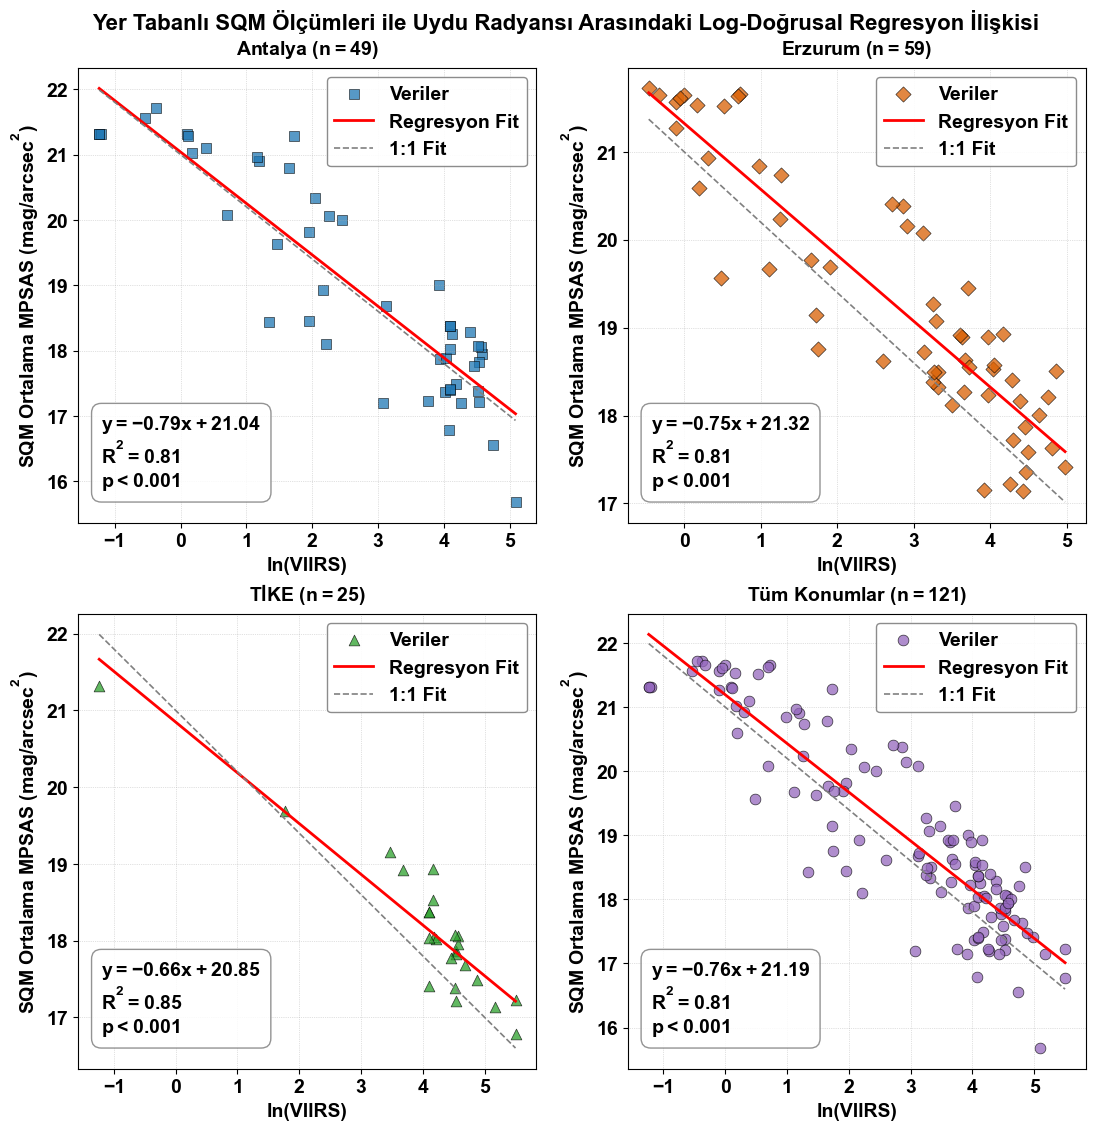

In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import linregress
import warnings
# Uyarıları kapatıyoruz
warnings.filterwarnings('ignore')

# ==========================================
# GÖRSEL AYARLAR (rcParams)
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.size'] = 14              # Genel varsayılan yazı boyutu
plt.rcParams['font.weight'] = 'bold'         # Genel kalın yazı
plt.rcParams['axes.labelsize'] = 14          # Eksen etiketleri boyutu
plt.rcParams['axes.titlesize'] = 14          # Alt grafik başlıkları boyutu
plt.rcParams['xtick.labelsize'] = 14         # X koordinat tick boyutları
plt.rcParams['ytick.labelsize'] = 14         # Y koordinat tick boyutları
plt.rcParams['legend.fontsize'] = 14         # Lejant yazı boyutu
plt.rcParams['figure.titlesize'] = 16        # Ana figür başlığı boyutu

# ==========================================
# VERİ YÜKLEME, FİLTRELEME VE BİRLEŞTİRME
# ==========================================
sqm_veri_klasoru = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\sqm\\SQM_VERI_2025'
urun_turu = 'VNP46A2'

bolgeler = {
    'Antalya': os.path.join(sqm_veri_klasoru, f"SQM_DUZENLI_VERI_ANTALYA_{urun_turu}.txt"),
    'Erzurum': os.path.join(sqm_veri_klasoru, f"SQM_DUZENLI_VERI_ERZURUM_{urun_turu}.txt"),
    'TİKE': os.path.join(sqm_veri_klasoru, f"SQM_DUZENLI_VERI_TIKE_{urun_turu}.txt")
}

veri_sozlugu = {}
tum_temiz_df = []

for bolge_adi, dosya_yolu in bolgeler.items():
    if os.path.exists(dosya_yolu):
        df = pd.read_csv(dosya_yolu, sep='\t')
        
        # --- AYKIRI DEĞERLERİN (OUTLIERS) FİLTRELENMESİ ---
        if bolge_adi in ['Antalya']:
            df = df[~df['Konum'].isin(['BELEDC','CAGMR1', 'CAGMR2'])]
        elif bolge_adi == 'Erzurum':
            df = df[~df['Konum'].isin(['ISPMER', 'ABDURG', 'TORTUK', 'DAGREZ'])]
        elif bolge_adi == 'TİKE':
            df = df[~df['Konum'].isin(['BELEDC', 'CAGMR1', 'CAGMR2'])]
        # ------------------------------------------------
        
        df = df.dropna(subset=['Ortalama_MPSAS (mag/arcsec^2)', f'VIIRS_{urun_turu}_3x3'])
        
        # Bölge sözlüğüne kaydediyoruz (Ayrı paneller için)
        veri_sozlugu[bolge_adi] = df
        
        # Ortak havuz için biriktiriyoruz
        tum_temiz_df.append(df)
    else:
        print(f"SONUC_RAPORU: UYARI - {bolge_adi} dosyası bulunamadı: {dosya_yolu}")

# --- MÜKERRER (TEKRAR EDEN) KONUMLARIN TEMİZLENMESİ ---
# Tüm verileri birleştirip, aynı koordinata veya konuma sahip mükerrer istasyonları eliyoruz
if len(tum_temiz_df) > 0:
    birlesik_df = pd.concat(tum_temiz_df, ignore_index=True)
    # Hem koordinat hem de isim bazında çakışanlar varsa tekilleştirilir
    birlesik_df = birlesik_df.drop_duplicates(subset=['Konum', 'Enlem (Derece)', 'Boylam (Derece)'])
    veri_sozlugu['Tüm Konumlar'] = birlesik_df

# ==========================================
# 2x2 DAĞILIM GRAFİĞİ VE REGRESYON ÇİZİMİ
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(13, 13))
plt.subplots_adjust(hspace=0.2, wspace=0.2)

# Tüm konumlar için renk ve marker tanımlanmıştır
panel_konumlari = [
    ('Antalya', axs[0, 0], '#1f77b4', 's'),
    ('Erzurum', axs[0, 1], '#d95f02', 'D'),
    ('TİKE', axs[1, 0], '#2ca02c', '^'),
    ('Tüm Konumlar', axs[1, 1], '#9467bd', 'o')
]

for bolge_adi, ax, renk, marker_tipi in panel_konumlari:
    if bolge_adi not in veri_sozlugu:
        continue
        
    df_b = veri_sozlugu[bolge_adi]
    
    gecerli_maske = df_b[f'VIIRS_{urun_turu}_3x3'] > 0
    x_log_viirs = np.log(df_b.loc[gecerli_maske, f'VIIRS_{urun_turu}_3x3'].values)
    y_sqm = df_b.loc[gecerli_maske, 'Ortalama_MPSAS (mag/arcsec^2)'].values
    
    # Doğrusal Regresyon Hesabı (OLS)
    egim, intercept, r_value, p_value, std_err = linregress(x_log_viirs, y_sqm)
    r2 = r_value ** 2
    
    x_fit = np.linspace(x_log_viirs.min(), x_log_viirs.max(), 100)
    y_fit = x_fit * egim + intercept
    
    # Çizimler
    ax.scatter(x_log_viirs, y_sqm, color=renk, marker=marker_tipi, s=60, alpha=0.75, edgecolors='k', linewidths=0.5, label='Veriler')
    ax.plot(x_fit, y_fit, color='red', linestyle='-', linewidth=2.0, label='Regresyon Fit')
    ax.plot(x_fit, x_fit * (-0.8) + 21.0, color='gray', linestyle='--', linewidth=1.2, label='1:1 Fit')

    ax.set_title(f'{bolge_adi} ($n = {len(x_log_viirs)}$)', fontweight='bold', pad=10)
    ax.set_xlabel('ln(VIIRS)', fontweight='bold')
    ax.set_ylabel('SQM Ortalama MPSAS ($mag/arcsec^2$)', fontweight='bold')
    ax.grid(True, which='both', linestyle=':', linewidth=0.5, color='#aaaaaa', alpha=0.7)
    
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    
    denklem_metni = f'$y = {egim:.2f}x + {intercept:.2f}$\n$R^2 = {r2:.2f}$\n$p < 0.001$'
    ax.text(0.05, 0.08, denklem_metni, transform=ax.transAxes, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.85))
    
    ax.legend(loc='upper right', frameon=True, edgecolor='gray', facecolor='white', framealpha=0.9)

# Üst Başlık
fig.suptitle(f'Yer Tabanlı SQM Ölçümleri ile Uydu Radyansı Arasındaki Log-Doğrusal Regresyon İlişkisi', fontweight='bold', y=0.925)

# Kaydetme
cikti_klasoru = '=cikti/sqm-viirs'
if not os.path.exists(cikti_klasoru):
    os.makedirs(cikti_klasoru)

cikti_yolu = os.path.join(cikti_klasoru, f'SONUC_RAPORU_SQM-VIIRS_01_{urun_turu}_regresyon_analizi.png')
plt.savefig(cikti_yolu, dpi=500, bbox_inches='tight', facecolor='white')

print('SONUC_RAPORU: ' + '='*80)
print(f"SONUC_RAPORU: 2x2 Regresyon Grafiği Başarıyla Kaydedildi : {cikti_yolu}")
for b_adi, d_set in veri_sozlugu.items():
    print(f"SONUC_RAPORU: {b_adi} bölgesinde analize katılan veri sayısı (n) : {len(d_set)}")
print('SONUC_RAPORU: ' + '='*80)

plt.show()
plt.close()



## **2.4.1 Regresyon Sonrası Tanısal Analizler ve Artık (Rezidü) Dağılımları**

- Geliştirdiğimiz logaritmik regresyon modelinin (transfer fonksiyonunun) istatistiksel güvenilirliğini ve hata yapısını sınamak amacıyla, regresyon sonrası artık analizleri gerçekleştirilmiştir.

- Rezidü, gözlemlenen gerçek SQM değerleri ile modelin tahmin ettiği değerler arasındaki farkı (n=121) elde edilen tahmin değerlerine karşılık rezidülerin saçılım grafiğini (üst panel) ve model hatalarının normal dağılıma uygunluğunu test eden frekans histogramını (alt panel) iki panelli bir grafik halinde görselleştirmektedir.

- Bu analiz; modelin sistematik bir yanlılık (bias) içerip içermediğini, hataların sıfır etrafında simetrik olarak dağılıp dağılmadığını ve Gauss (normal) dağılım varsayımını doğrulamak için kritik bir tanısal araç görevi görür.


SONUC_RAPORU: ================================================================================
SONUC_RAPORU: Rezidü Tanısal Analiz Grafiği Başarıyla Hesaplandı ve Kaydedildi : =cikti/sqm-viirs\SONUC_RAPORU_SQM-VIIRS_02_rezidu_analizi.png
SONUC_RAPORU: Toplam İstasyon Sayısı (n) : 121
SONUC_RAPORU: ================================================================================


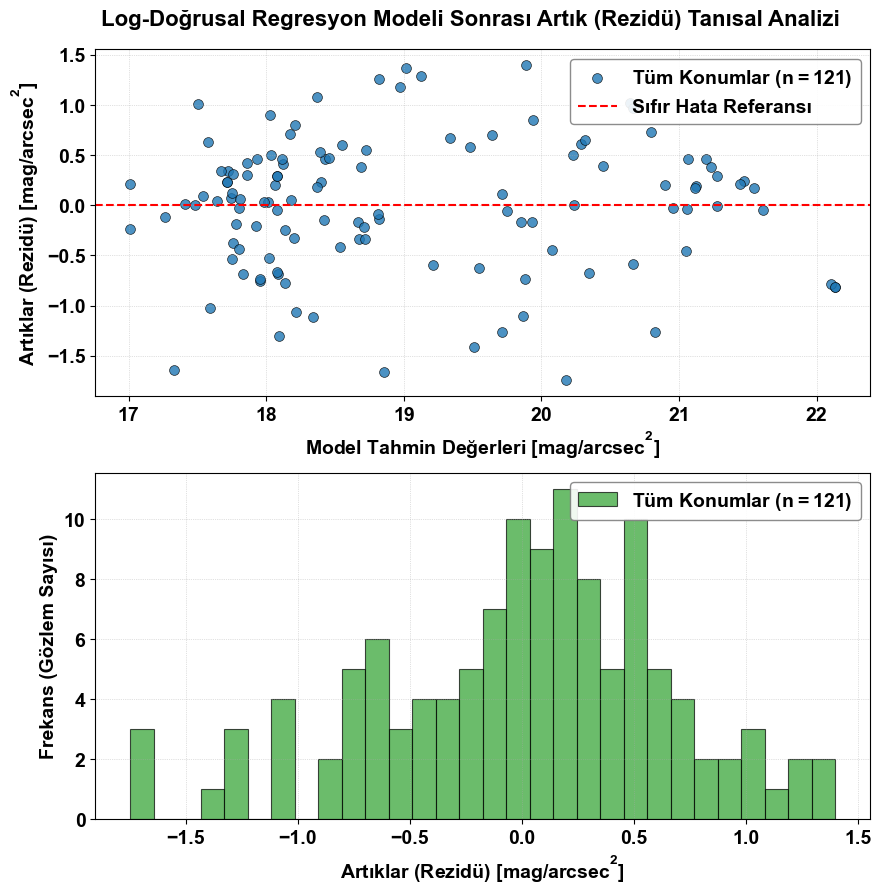

In [1]:

# Gerekli modülleri içe aktarıyoruz
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import linregress
import warnings
# Uyarıları kapatıyoruz
warnings.filterwarnings('ignore')

# ==========================================
# GÖRSEL AYARLAR (rcParams)
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Helvetica', 'sans-serif']
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.size'] = 14              # Genel varsayılan yazı boyutu
plt.rcParams['font.weight'] = 'bold'         # Genel kalın yazı
plt.rcParams['axes.labelsize'] = 14          # Eksen etiketleri boyutu
plt.rcParams['axes.titlesize'] = 14          # Alt grafik başlıkları boyutu
plt.rcParams['xtick.labelsize'] = 14         # X koordinat tick boyutları
plt.rcParams['ytick.labelsize'] = 14         # Y koordinat tick boyutları
plt.rcParams['legend.fontsize'] = 14         # Lejant yazı boyutu
plt.rcParams['figure.titlesize'] = 16        # Ana figür başlığı boyutu

# ==========================================
# 1. VERİLERİ YÜKLEME, FİLTRELEME VE BİRLEŞTİRME
# ==========================================
sqm_veri_klasoru = 'E:\\=PROJELER\\=TUBITAK_3501_2024\\veri\\sqm\\SQM_VERI_2025'
urun_turu = 'VNP46A2'

bolgeler = {
    'Antalya': os.path.join(sqm_veri_klasoru, f"SQM_DUZENLI_VERI_ANTALYA_{urun_turu}.txt"),
    'Erzurum': os.path.join(sqm_veri_klasoru, f"SQM_DUZENLI_VERI_ERZURUM_{urun_turu}.txt"),
    'TİKE': os.path.join(sqm_veri_klasoru, f"SQM_DUZENLI_VERI_TIKE_{urun_turu}.txt")
}

tum_temiz_df = []

for bolge_adi, dosya_yolu in bolgeler.items():
    if os.path.exists(dosya_yolu):
        df = pd.read_csv(dosya_yolu, sep='\t')
        
        # Aykırı değerlerin (outliers) filtrelenmesi
        if bolge_adi in ['Antalya']:
            df = df[~df['Konum'].isin(['BELEDC','CAGMR1', 'CAGMR2'])]
        elif bolge_adi == 'Erzurum':
            df = df[~df['Konum'].isin(['ISPMER', 'ABDURG', 'TORTUK', 'DAGREZ'])]
        elif bolge_adi == 'TİKE':
            df = df[~df['Konum'].isin(['BELEDC', 'CAGMR1', 'CAGMR2'])]
            
        df = df.dropna(subset=['Ortalama_MPSAS (mag/arcsec^2)', f'VIIRS_{urun_turu}_3x3'])
        tum_temiz_df.append(df)
    else:
        print(f"SONUC_RAPORU: UYARI - {bolge_adi} dosyası bulunamadı: {dosya_yolu}")

if len(tum_temiz_df) == 0:
    raise FileNotFoundError("SONUC_RAPORU: HATA - İşlenecek hiçbir SQM-VIIRS eşleşme dosyası bulunamadı!")

# --- MÜKERRER (TEKRAR EDEN) KONUMLARIN TEMİZLENMESİ ---
# Tüm bölgeleri birleştirip, aynı koordinata veya konuma sahip mükerrer istasyonları eliyoruz
viirs_tablo = pd.concat(tum_temiz_df, ignore_index=True)
viirs_tablo = viirs_tablo.drop_duplicates(subset=['Konum', 'Enlem (Derece)', 'Boylam (Derece)'])

# ==========================================
# 2. REGRESYON VE REZİDÜ (ARTIK) HESABI
# ==========================================
gecerli_maske = viirs_tablo[f'VIIRS_{urun_turu}_3x3'] > 0
x_log_viirs = np.log(viirs_tablo.loc[gecerli_maske, f'VIIRS_{urun_turu}_3x3'].values)
y_sqm_gozlem = viirs_tablo.loc[gecerli_maske, 'Ortalama_MPSAS (mag/arcsec^2)'].values

# OLS Regresyon katsayılarının türetilmesi
egim, intercept, r_value, p_value, std_err = linregress(x_log_viirs, y_sqm_gozlem)

# Model Tahmin Değerleri (SQM Tahmin)
y_sqm_tahmin = x_log_viirs * egim + intercept

# Rezidü / Fark Hesabı: (Gözlem - Tahmin)
reziduler = y_sqm_gozlem - y_sqm_tahmin

# Geçici analiz tablosu oluşturuluyor
analiz_df = pd.DataFrame({
    'Tahmin': y_sqm_tahmin,
    'Gözlem': y_sqm_gozlem,
    'Fark': reziduler
})

n_gozlem = len(analiz_df)

# ==========================================
# 3. 2 PANELLİ REZİDÜ (ARTIK) GÖRSELLEŞTİRME
# ==========================================
fig, ax = plt.subplots(figsize=(10, 10), nrows=2, ncols=1)
plt.subplots_adjust(hspace=0.22)

# 1. Panel: Tahmin Değerlerine Karşı Rezidüler (Saçılım Grafiği)
ax[0].scatter(analiz_df['Tahmin'], analiz_df['Fark'], color='#1f77b4', s=50, alpha=0.8, edgecolors='k', linewidths=0.5)
ax[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Sıfır Hata Referansı')

# 2. Panel: Rezidü Dağılım Histogramı (Normallik Testi)
ax[1].hist(analiz_df['Fark'], bins=30, color='#2ca02c', edgecolor='black', linewidth=0.8, alpha=0.7)

# Eksen Etiketleri ve Lejantlar
ax[0].set_xlabel('Model Tahmin Değerleri [$mag/arcsec^2$]', fontweight='bold')
ax[0].set_ylabel('Artıklar (Rezidü) [$mag/arcsec^2$]', fontweight='bold')
ax[0].legend([f'Tüm Konumlar ($n = {n_gozlem}$)', 'Sıfır Hata Referansı'], loc='upper right', frameon=True, edgecolor='gray', facecolor='white', framealpha=0.9)

ax[1].set_xlabel('Artıklar (Rezidü) [$mag/arcsec^2$]', fontweight='bold')
ax[1].set_ylabel('Frekans (Gözlem Sayısı)', fontweight='bold')
ax[1].legend([f'Tüm Konumlar ($n = {n_gozlem}$)'], loc='upper right', frameon=True, edgecolor='gray', facecolor='white', framealpha=0.9)

# Grid çizgileri
ax[0].grid(True, which='both', linestyle=':', linewidth=0.5, color='#aaaaaa', alpha=0.7)
ax[1].grid(True, which='both', linestyle=':', linewidth=0.5, color='#aaaaaa', alpha=0.7)

# Başlık
fig.suptitle('Log-Doğrusal Regresyon Modeli Sonrası Artık (Rezidü) Tanısal Analizi', fontweight='bold', y=0.92)

# Çıktı klasörünü kontrol edip oluşturuyoruz
cikti_klasoru = '=cikti/sqm-viirs'
if not os.path.exists(cikti_klasoru):
    os.makedirs(cikti_klasoru)

# Kaydetme
cikti_yolu = os.path.join(cikti_klasoru, 'SONUC_RAPORU_SQM-VIIRS_02_rezidu_analizi.png')
plt.savefig(cikti_yolu, dpi=500, bbox_inches='tight', facecolor='white')

print('SONUC_RAPORU: ' + '='*80)
print(f"SONUC_RAPORU: Rezidü Tanısal Analiz Grafiği Başarıyla Hesaplandı ve Kaydedildi : {cikti_yolu}")
print(f"SONUC_RAPORU: Toplam İstasyon Sayısı (n) : {n_gozlem}")
print('SONUC_RAPORU: ' + '='*80)

plt.show()
plt.close()



## **2.5 Bölüm Özeti**

- Bu eğitim ve uygulama dosyasında, yer tabanlı SQM gözlemlerimizin uydu verileriyle doğrulanabilmesi ve regresyon analizlerine hazır hale getirilmesi amacıyla; NASA'nın günlük olarak sunduğu VNP46A1 ve VNP46A2 ürünlerinin otomatik işleme hattı kurgulanmıştır. Gerçekleştirilen işlemler aşağıda özetlenmiştir:

**1. Uydu Veri Yapısı ve Dinamik Projeksiyon Dönüşümü**

- NASA LAADS DAAC platformundan indirilen HDF5 formatındaki günlük uydu dosyaları Python ortamına aktarılmıştır.

- Geliştirilen hdf_geotiff_donustur fonksiyonu sayesinde, üst kısımda seçilen ürün türüne (VNP46A1 veya VNP46A2) göre hedef gece ışığı radyans katmanları HDF5 alt veri kümeleri içerisinden dinamik olarak ayıklanmıştır.

- Her bir görüntünün metadata bilgileri taranarak Sinüzoidal grid köşe koordinatları otomatik olarak hesaplanmış ve veriler WGS84 coğrafi koordinat sistemine (EPSG:4326) hassas bir şekilde projekte edilmiştir.

**2. Sanal Raster Mozaikleme ve Temizleme**

- Türkiye genelini kapsayan ancak ayrık hücreler halinde bulunan Sinüzoidal grid pikselleri, geotiff_birlestir fonksiyonu altında bir araya getirilmiştir.

- GDAL sanal raster (VRT) mimarisi kullanılarak görüntüler bir döngüyle mozaiklenmiş, yapay radyans verisi için boş değer (NoData) sınırı -999.9 olarak atanmış ve tek bir bütünleşik Türkiye haritası üretilmiştir. İşlemi tamamlanan geçici ara dosyalar otomatik olarak silinmiştir.

**3. GADM Vektör Sınırları ile Coğrafi Maskeleme**

- Üretilen mozaik GeoTIFF görüntülerinin, uluslararası GADM (Sürüm 4.1) veri tabanından elde edilen Türkiye ulusal kara sınırı shapefile (TUR_0) dosyası kullanılarak maskelenmesi sağlanmıştır.

- geotiff_dosya_kes fonksiyonu altında GDAL gdalwarp aracı koordine edilerek görüntüler Türkiye sınırlarına göre kırpılmıştır.

**4. Yer-Uydu Zamansal ve Mekânsal Çakıştırma**

- Bir önceki notebook dosyasında hazırladığımız düzenli SQM tabloları uydunun günlük geçiş takvimiyle bütünleştirilmiştir.

- Geliştirilen yer_uydu_veri_cakistir fonksiyonu; her bir yer gözleminin yapıldığı günün tarihini ve istasyonun coğrafi koordinatlarını referans alarak o güne ait Türkiye kesilmiş günlük GeoTIFF dosyasını otomatik olarak bulmaktadır.

- SQM ölçüm koordinatlarına en yakın piksel indeksleri saptanarak, 1x1 piksel ile onu çevreleyen tampon bölge değeri (3x3 piksel) eş zamanlı olarak okunmuştur.

- Bu veriler yer tabanlı SQM tablomuza yeni sütunlar olarak eklenmiş ve regresyon işlemlerinin ana girdisini oluşturacak bütünleşik veri tablosu başarıyla üretilmiştir.

**5. Regresyon Analizi**

- Kurduğumuz logaritmik transfer fonksiyonu (regresyon modeli) ve ardından gerçekleştirdiğimiz artık (rezidü) analizinin temel bilimsel sonuçları yüksek determinizm ve güçlü korelasyon olduğunu doğrulamaktadır.

- Regresyon sonrası gerçekleştirilen artık (Rezidü = Gözlem-Tahmin) analizinde, artıkların sıfır (0) hata çizgisi etrafında hiçbir sistematik eğilim veya eğrilik göstermeksizin, tamamen rastgele ve simetrik bir dağılım sergilediği görülmüştür.

- Regresyon denklemi ve artık analizlerinden elde edilen bu istatistiksel kararlılık, türetilen transfer fonksiyonlarının tüm çalışma alanı genelinde kesintisiz kadir ($mag/arcsec^2$) haritalarının üretilmesi ve uzun vadeli zaman serisi modellemeleri için güvenle kullanılabileceğini tescil etmiştir.



## **Yapay Zeka Kullanım Beyanı**

- Bu çalışmanın Python kodlarının geliştirilmesi, veri analiz algoritmalarının optimizasyonu, İngilizce-Türkçe akademik çeviriler ve raporlama süreçlerinde yapay zeka asistanından (Google Gemini) teknik ve dilsel destek alınmıştır. Çalışmanın bilimsel doğruluğu, veri bütünlüğü ve nihai raporlama sorumluluğu tamamen araştırmacılara aittir.



- **Kaynak:**

Kaba, K., Aydın, S., Türkmen, R. B., Polat, F., Aksoy, F., Nasıroğlu, İ., Yeşilyaprak, C., Kandırmaz, H. M.  (2026b). Long-term dynamics and machine learning-based mapping of night sky brightness: snowglow, urbanization, and topography effects at major astronomical observatories in Türkiye. Experimental Astronomy, 62, 16. https://doi.org/10.1007/s10686-026-10076-6
